# Module 4: Programming Assignment

In [1]:
library(testthat)
library(ggplot2)

expect_constant = function(actual, tolerance = .Machine$double.eps^0.5) {
  if (length(actual) == 0) {
    fail("The vector is empty.")
  }
  
  # Check if all elements are the same within the given tolerance
  if (all(abs(actual - actual[1]) < tolerance)) {
    succeed()
  } else {
    fail("Your answer is not proportional to the posterior.")
  }
}

## Problem 1: An objective analysis in R

**1 (a) [10 points] Assume that the data $\mathbf{x} = (0.4478, 0.6173, 1.1317, 0.9011, 1.9250)$ are realizations from $X_1, X_2, X_3, X_4, X_5 \overset{iid}{\sim} \Gamma(1,\lambda)$. Conduct an "objective" Bayesian analysis using Jeffreys prior, $\pi(\lambda)$, and data $\mathbf{x}$.** 

**Note: In videos in this module, we saw that, for parameter $\lambda$, $\pi(\lambda) \propto \sqrt{I(\lambda)}$, where $I(\lambda)$ is the Fisher Information number for the data. For the purposes of this problem use $\pi(\lambda) = 1/20\sqrt{I(\lambda)}$ when calculating the prior, for reasons that will become clear later in the question.**


Step by step: 

- Start by mathematically deriving the Jeffreys prior in this context. HINT: from a video in this module, the Fisher Information is most easily computed using the formula $$I(\lambda) = -E\left[ \frac{d^2}{d\lambda^2}\log\left(f(\mathbf{x} \, | \, \lambda )\right)\right],$$ where $f(\mathbf{x} \, | \, \lambda )$ is the likelihood function for the data. Be sure to multiply by $c = 1/20$ to obtain $\pi(\lambda)$.

- Then, in R, compute this Jeffreys prior for $m = 200$ evenly spaced $\lambda$ values between 0.1 and 2 (i.e., use `lambda = seq(0.1,2,length.out=200)`). Store the results in a vector labeled, `prior`.

- Finally, in R, compute exact posterior distribution (including the denominator of Bayes Theorem!) given the data for the same $m = 200$ evenly spaced $\lambda$ values between 0.1 and 2. Store the values for the posterior in a vector labeled, `post`.

Use R functions for your answer; this will make part (c) easier!

In [11]:
x = c(0.4478, 0.6173, 1.1317, 0.9011, 1.9250)

In [39]:
# your code here
#.NotYetImplemented()
n = length(x)
#mean(x)
lambda = seq(0.1,2,length.out=200)
#prior = (1/20) * (sqrt(n) / lambda)

prior_func <- function(lamb) {
    (1/20) * (sqrt(n) / lamb)
}

likelihood_func <- function(lamb) {
    ll = 1
    for (i in 1:n) {
        ll <- ll * dgamma(x[i], shape=1, rate=lamb)
    }
    ll
}

posterior_func <- function(lamb) {
    likelihood_func(lamb)*prior_func(lamb) / integrate(function(l) likelihood_func(l)*prior_func(l), 0, Inf)$val
}

prior <- prior_func(lambda)
post <- posterior_func(lambda)                                                       
                                             
#l <- sapply(lambda, likelihood)
#l <- lambda^n * exp(-lambda * sum(x))
#post <- l*prior / sum(l*prior)

#post <- dgamma(lambda, shape=n, rate=sum(x))
#post

**1 (b) [7 points] Plot the prior and posterior distributions on the same plot using ggplot and store the plot as variable, `p`.**

(The reason we chose a prior with a multiplier of $c = 1/20$ was so that the prior and posterior would be scaled for the same plot!)

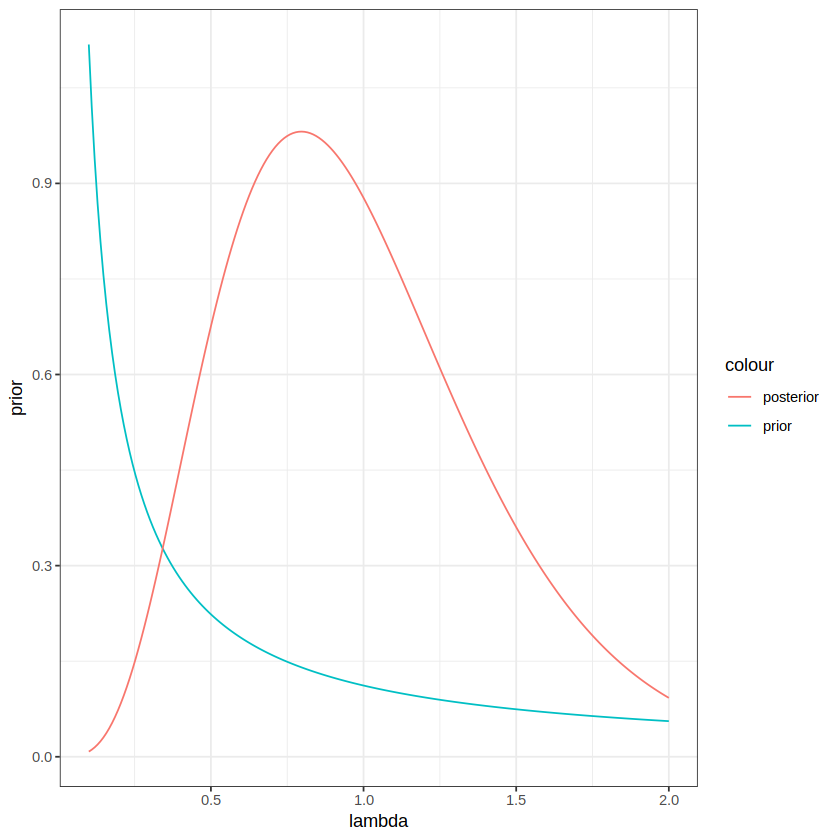

In [40]:
# your code here
#.NotYetImplemented()
#df <- data.frame(lambda=lambda, prior=prior, ll=l, posterior=post)
df <- data.frame(lambda=lambda, prior=prior, posterior=post)
p <- ggplot(df) + geom_line(aes(lambda, prior, col='prior')) +
                #geom_line(aes(lambda, ll, col='likelihood')) +
                geom_line(aes(lambda, post, col='posterior')) +
                theme_bw()
p

**1 (c) [4 points] Numerically verify that the posterior is proper by checking that the posterior integrates to 1. Store the result of the integrate function in a variable labeled, `verification`.  Note: `integrate()` returns a list.  Be sure your variable `verification` is a list resulting from a call to the `integrate` function.**

In [42]:
# your code here
#.NotYetImplemented()
verification = integrate(posterior_func, 0, Inf)
#verification$val

[1] 1

## Problem 2: From the prior to the posterior predictive distribution

Let $X_1,...,X_n \overset{iid}{\sim}N(\mu, \sigma^2)$ with $\sigma^2$ known and $\mu \sim N(\mu_0, \sigma^2_0)$. That is, we are working with a normal-normal conjugate prior scenario. If we let $\sigma^2_0$ be very large, then we are effectively working with the Jeffreys prior $\pi(\mu) = c$, for any constant $c$. That is because, as $\sigma^2_0 \to \infty$,the pdf of a $N(\mu_0, \sigma^2_0)$ converges to a flat line over the real number line.

Define the *prior predictive distribution* as 

\begin{align*}
f_{\text{prior}}(x^* ) = \int f(x^* \, | \, \theta)\pi(\theta)d\theta,
\end{align*}

where $f(x^* \, | \, \theta)$ is the marginal likelihood for a new observation of $X^* = x^*$. One might use this prior predictive distribution to make predictions in the absence of new data. Once new data are observed (as in part (d) below), one should use the *posterior* predictive distribution as described in videos earlier in this course. 


Given this definition, one can show that $X^*  \sim N(\mu_0,\    \sigma^2 + \sigma^2_0)$. But, to avoid having to do the integral, let's use Monte Carlo simulations!


**2 (a) [5 points] Run a Monte Carlo simulation to verify $X^*  \sim N(\mu_0,\    \sigma^2 + \sigma^2_0)$ numerically. Specifically,**

1. Generate $N = 100,000$ values of $\mu$ from the prior $\pi(\theta) = N(\mu_0 = 10,\sigma_0^2 = 1000)$ (technically a normal prior, but with such a large variance, it is close to the Jeffreys prior). Store these values in a vector labeled `mu`.

2. Generate $N = 100,000$ values of $x^*$ from the (marginal) likelihood $f(x^* \, | \, \theta) = N(\mu, \sigma^2 = 9)$, where $\mu$ are the values in `mu`. Save these values in a vector labeled `xstar`.

3. Use these values to calculate the mean and variance of the prior predictive distribution for $X^*$.  Store the mean in a variable labeled `pp_mean` and the variance in a variable labeled `pp_var`. Note: `pp_mean` and `pp_var` should reflect the theoretical result $X^*  \sim N(\mu_0,\    \sigma^2 + \sigma^2_0)$.


In [46]:
# your code here
#.NotYetImplemented()

set.seed(0110)
N = 100000  # number of draws from the posterior predictive distribution
mu0 <- 10
sigma0 <- sqrt(1000)
sigma <- 3
mu <- rnorm(N, mu0, sigma0)
xstar <- rnorm(N, mu, sigma)
pp_mean <- mean(xstar)
pp_var <- var(xstar)
pp_mean
pp_var

[1] 9.904367

[1] 1008.549

In [45]:
set.seed(0110)

**2 (b) [1 point] Using ggplot, plot a histogram of the draws from the prior predictive distribution and save it in a variable labeled `pp_p`.**  

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


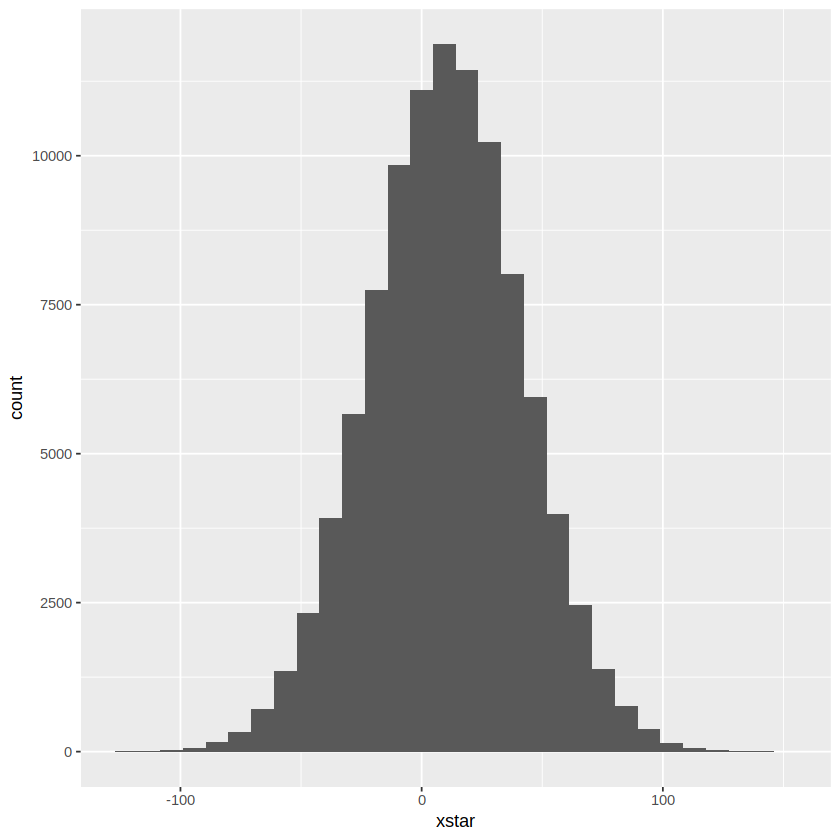

In [47]:
# your code here
#.NotYetImplemented()
pp_p <- ggplot(data.frame(xstar=xstar)) + geom_histogram(aes(xstar))
pp_p

**2 (c) [3 point] [Multiple Choice] What is the shape of the distribution?** 

Select the best response to this question and storing the number associated with the response in a variable labeled `choice`.    
1. The distribution is left skewed with a mode of 10. 
2. The distribution is bell-shaped (i.e. resembles a normal distribution) centered at 10.  
3. The distribution is right skewed with a mode of 10.

For example, if you believe the best response is #3, code: `choice=3` in the code block below.

In [48]:
# your code here
#.NotYetImplemented()
choice = 2

The goal of the next part is to move from the *prior* predictive distribution to the *posterior* predictive distribution. First, let's get the posterior for $\mu \, | \,  \mathbf{x}$. 

**2 (d) [10 points] Generate a set of $n = 40$ iid observation from a normal distribution with a mean of $7$, and a variance given above in part (a) ($\sigma^2 = 9$). These will be our "synthetic" data for a Bayesian analysis. Use these data, along with the prior given in part (a), to do compute the exact posterior distribution based on the normal-normal conjugate prior relationsip. Store the mean in a variable labeled `post_mean` and the variance in a variable labeled `post_var`.**

In [55]:
# your code here
#.NotYetImplemented()
set.seed(0110)
mu0 <- 10
sigma0 <- sqrt(1000)
n = 40
sigma = 3
x <- rnorm(n, 7, sigma)
xbar <- mean(x)
post_mean <- (mu0 / sigma0^2 + n * xbar / sigma^2) / (1 / sigma0^2 + n / sigma^2)
post_var <- 1 / (1 / sigma0^2 + n / sigma^2)
post_mean
post_var

[1] 7.44995

[1] 0.2249494

Now let's get the *posterior* predictive distribution for $X^* \, | \,\mathbf{x}$. As defined in this course, the *posterior predictive distribution* as 

\begin{align*}
f_{\text{post}}(x^* \, | \, \mathbf{x}) = \int f(x^* \, | \, \mu)\pi(\mu \, | \, \mathbf{x})d\theta,
\end{align*}

where $f(x^* \, | \, \mu)$ is the marginal likelihood for a new observation of $X^* = x^*$ (with $\sigma^2 = 9$). In order to avoid computing this integral, we can estimate the posterior predictive distribution through Monte Carlo simulation.



**2 (e) [10 points] Simulate from the posterior predictive distribution for $X^* \, | \, \mathbf{x}$ with the following steps:**

- Simulate $N = 100,000$ values from $\mu \, | \, \mathbf{x}$. Store these values in a vector `mustar`.

- Simulate $N = 100,000$ values from the distribution $f(x^* \, | \, \mu)$, where $f$ is the likelihood for the data (i.e., normal), centered at the values in `mustar` with known variance $\sigma^2 = 9$. Store these values in a vector `xstar_post`.

- Finally, compute the mean and variance of `xstar_post`. Store these values in `xstar_post_bar` and `xstar_post_var`, respectively.

HINT: You shouldn't need a loop here. Just two lines using `rnorm()` should work!

In [52]:
# your code here
#.NotYetImplemented()
mustar <- rnorm(N, post_mean, sqrt(post_var))
xstar_post <- rnorm(N, mustar, sigma)
xstar_post_bar <- mean(xstar_post)
xstar_post_var <- var(xstar_post)
xstar_post_bar
xstar_post_var
#hist(xstar_post)

[1] 7.10753

[1] 9.210335

**2 (f) [3 point] [Multiple Choice] Comparing the above distributions.** 

Consider the following claims: 

1. The posterior distribution is centered at roughly the same place as the posterior predictive distribution.
2. All of these distributions are roughly bell-shaped (i.e. resemble a normal distribution) centered at 10.  
3. The posterior distribution has roughly the same variance as the posterior predictive distribution.
4. The posterior predictive distribution has a larger variance than the posterior distribution because the posterior predictive distribution accounts for uncertainty in both the parameter $\mu$ and new predicted value $X^*$.
5. There is more uncertainty in $\mu \, | \, \mathbf{x}$ than there is in the the new prediction $X^* \, | \, \mathbf{x}$.
6. There is more uncertainty in the prior predictive distribution than the posterior predictive distribution. 

Which of these claims are true?  

**A. 1 only.**

**B. 1 and 2 only.**

**C. 1, 2, and 3 only.**

**D. 1, 2, 4 only.**

**E. 1, 2, 5 only.**

**F. 1, 3, and 6 only.**

**G. 1, 2, 4, and 6 only**

**H. All of the claims are true.**



Answer this question by storing the letter (as a string) in the variable `choice`. For example, if you believe the best response is B, the code would be: `choice="B"`. 

In [53]:
# your code here
#.NotYetImplemented()
choice = "G"

In [ ]:
choice_soln = NA